### XGBoost Model

#### First iteration

[0]	validation_0-rmse:45967.16683
[1]	validation_0-rmse:43125.41817
[2]	validation_0-rmse:40551.40735
[3]	validation_0-rmse:38228.96443
[4]	validation_0-rmse:36138.18685
[5]	validation_0-rmse:34172.59153
[6]	validation_0-rmse:32416.17696
[7]	validation_0-rmse:30898.86260
[8]	validation_0-rmse:29422.30816
[9]	validation_0-rmse:28083.00345
[10]	validation_0-rmse:26895.18493
[11]	validation_0-rmse:25861.76414
[12]	validation_0-rmse:24960.99609
[13]	validation_0-rmse:24082.59764
[14]	validation_0-rmse:23288.58338
[15]	validation_0-rmse:22713.42760
[16]	validation_0-rmse:22079.23408
[17]	validation_0-rmse:21666.50598
[18]	validation_0-rmse:21183.60433
[19]	validation_0-rmse:20709.07984
[20]	validation_0-rmse:20385.62858
[21]	validation_0-rmse:20010.53464
[22]	validation_0-rmse:19613.03991
[23]	validation_0-rmse:19248.61497
[24]	validation_0-rmse:19127.50600
[25]	validation_0-rmse:19037.36734
[26]	validation_0-rmse:18916.20907
[27]	validation_0-rmse:18766.44555
[28]	validation_0-rmse:18693.5

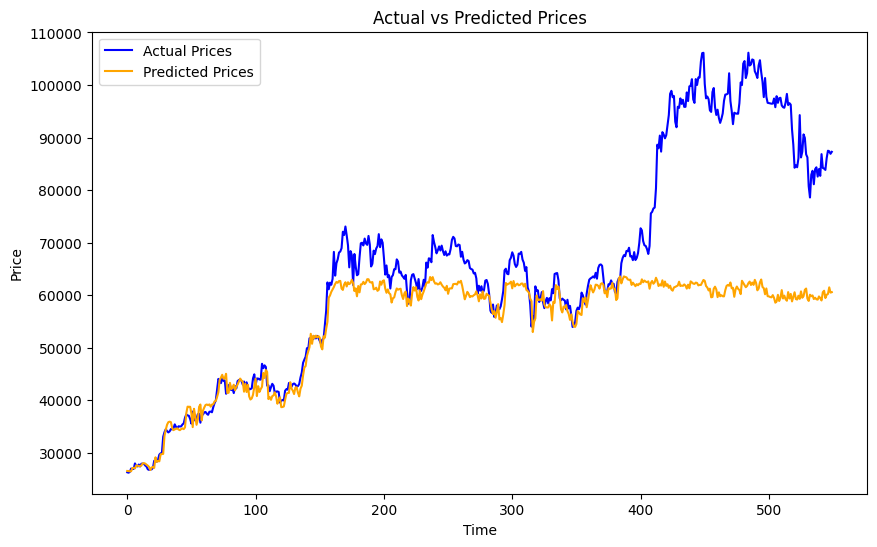

In [3]:
import xgboost
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import os

os.chdir('C:/Users/gerar/OneDrive/Documentos/GitHub/bitcoinPred')  # Set the working directory

# Load the processed dataset
file_path = "data/processed/btc_gradient_boosting.csv"
df = pd.read_csv(file_path)

# Separate features (X) and target (y)
X = df.drop(columns=["target"])  # All columns except the target
y = df["target"]  # The target column (next day's close price)

# Split the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Initialize the XGBoost model
model = XGBRegressor(
    n_estimators=100,  # Number of trees
    learning_rate=0.1,  # Step size shrinkage
    max_depth=6,  # Maximum depth of a tree
    subsample=0.8,  # Fraction of samples used for training each tree
    colsample_bytree=0.8,  # Fraction of features used for training each tree
    random_state=42,
    eval_metric="rmse"  # Specify the evaluation metric here
)

# Train the model
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],  # Validation set for early stopping
    verbose=True
)

# Make predictions on the validation set
y_val_pred = model.predict(X_val)

# Evaluate the model
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Plot actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.plot(y_val.values, label="Actual Prices", color="blue")
plt.plot(y_val_pred, label="Predicted Prices", color="orange")
plt.title("Actual vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

Seems like the model experiments problems when volatility increases

#### Hyperparameter Tuning

[0]	validation_0-rmse:47556.91523
[1]	validation_0-rmse:46050.95369
[2]	validation_0-rmse:44628.62435
[3]	validation_0-rmse:43249.61930
[4]	validation_0-rmse:41963.31903
[5]	validation_0-rmse:40722.67871
[6]	validation_0-rmse:39563.95819
[7]	validation_0-rmse:38464.69115
[8]	validation_0-rmse:37421.72777
[9]	validation_0-rmse:36423.55892
[10]	validation_0-rmse:35475.40745
[11]	validation_0-rmse:34484.25045
[12]	validation_0-rmse:33535.33453
[13]	validation_0-rmse:32641.20665
[14]	validation_0-rmse:31802.73688
[15]	validation_0-rmse:31069.59684
[16]	validation_0-rmse:30299.66999
[17]	validation_0-rmse:29645.03045
[18]	validation_0-rmse:28948.69475
[19]	validation_0-rmse:28287.38451
[20]	validation_0-rmse:27731.42242
[21]	validation_0-rmse:27139.32246
[22]	validation_0-rmse:26602.71633
[23]	validation_0-rmse:26071.12269
[24]	validation_0-rmse:25572.23807
[25]	validation_0-rmse:25118.57089
[26]	validation_0-rmse:24725.26061
[27]	validation_0-rmse:24317.60462
[28]	validation_0-rmse:23951.2

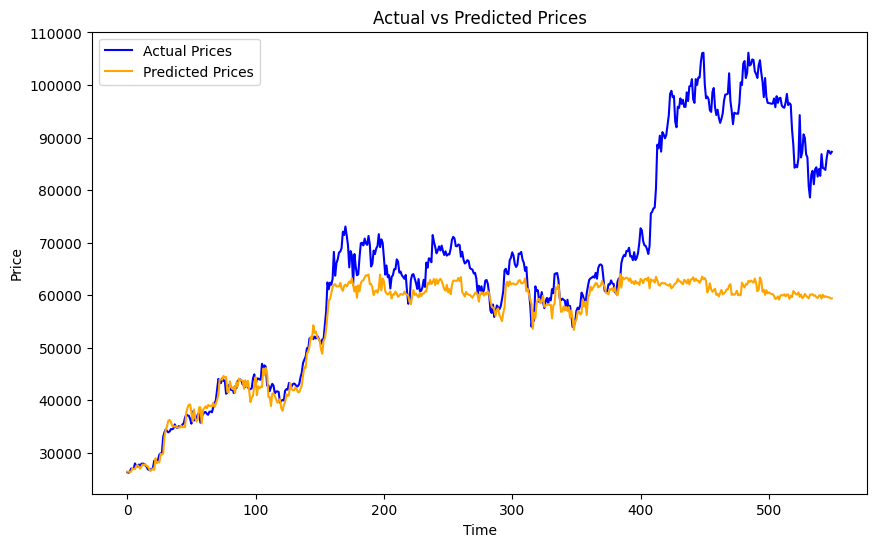

In [5]:
# Load the processed dataset
file_path = "data/processed/btc_gradient_boosting.csv"
df = pd.read_csv(file_path)

# Separate features (X) and target (y)
X = df.drop(columns=["target"])  # All columns except the target
y = df["target"]  # The target column (next day's close price)

# Split the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Initialize the XGBoost model
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="rmse"
)

# Train the model
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],  # Validation set for early stopping
   
    verbose=True
)

# Make predictions on the validation set
y_val_pred = model.predict(X_val)

# Evaluate the model
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Plot actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.plot(y_val.values, label="Actual Prices", color="blue")
plt.plot(y_val_pred, label="Predicted Prices", color="orange")
plt.title("Actual vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

Hyperparameter tuning doesnt help to improve model so far.

#### Data Normalization

[0]	validation_0-rmse:47556.91523
[1]	validation_0-rmse:46050.95369
[2]	validation_0-rmse:44628.62435
[3]	validation_0-rmse:43249.61930
[4]	validation_0-rmse:41963.31903
[5]	validation_0-rmse:40722.67871
[6]	validation_0-rmse:39563.95819
[7]	validation_0-rmse:38464.69115
[8]	validation_0-rmse:37421.72777
[9]	validation_0-rmse:36423.55892
[10]	validation_0-rmse:35475.40745
[11]	validation_0-rmse:34484.25045
[12]	validation_0-rmse:33535.33453
[13]	validation_0-rmse:32641.20665
[14]	validation_0-rmse:31802.73688
[15]	validation_0-rmse:31069.59684
[16]	validation_0-rmse:30299.66999
[17]	validation_0-rmse:29645.03045
[18]	validation_0-rmse:28948.69475
[19]	validation_0-rmse:28287.38451
[20]	validation_0-rmse:27731.42242
[21]	validation_0-rmse:27139.32246
[22]	validation_0-rmse:26602.71633
[23]	validation_0-rmse:26071.12269
[24]	validation_0-rmse:25572.23807
[25]	validation_0-rmse:25118.57089
[26]	validation_0-rmse:24725.26061
[27]	validation_0-rmse:24317.60462
[28]	validation_0-rmse:23951.2

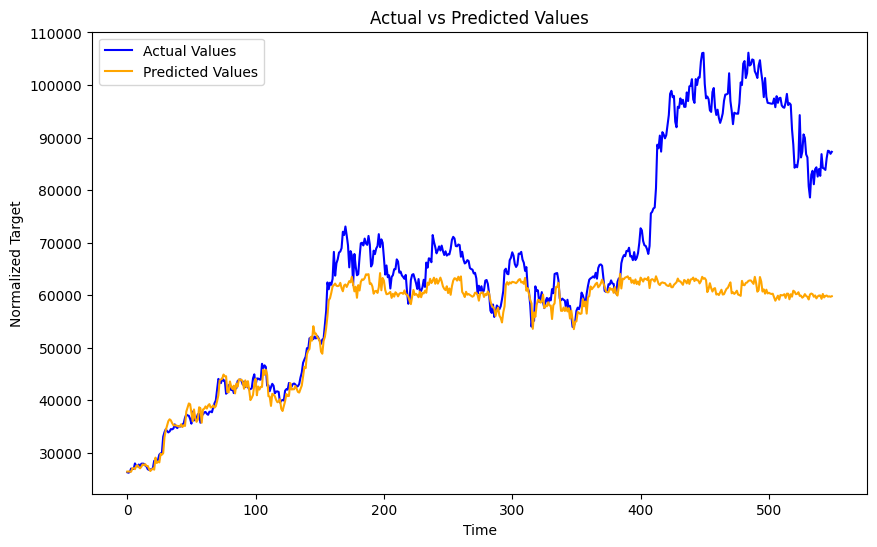

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the processed dataset
file_path = "data/processed/btc_gradient_boosting.csv"
df = pd.read_csv(file_path)

# Separate features (X) and target (y)
X = df.drop(columns=["target"])  # All columns except the target
y = df["target"]  # The target column (next day's close price)

# Split the data into training and validation sets (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Normalize the features using MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform the training set
X_val_scaled = scaler.transform(X_val)  # Transform the validation set (use the same scaler)

# Initialize the XGBoost model
model = XGBRegressor(
    n_estimators=300,  # Number of trees
    learning_rate=0.05,  # Step size shrinkage
    max_depth=8,  # Maximum depth of a tree
    subsample=0.8,  # Fraction of samples used for training each tree
    colsample_bytree=0.8,  # Fraction of features used for training each tree
    random_state=42,
    eval_metric="rmse"  # Evaluation metric
)

# Train the model
model.fit(
    X_train_scaled,
    y_train,
    eval_set=[(X_val_scaled, y_val)],
    verbose=True
)

# Make predictions on the validation set
y_val_pred = model.predict(X_val_scaled)

# Evaluate the model
mae = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_val.values, label="Actual Values", color="blue")
plt.plot(y_val_pred, label="Predicted Values", color="orange")
plt.title("Actual vs Predicted Values")
plt.xlabel("Time")
plt.ylabel("Normalized Target")
plt.legend()
plt.show()

Normalization does not help to improve the model either.

#### Insights
XGBoost seems like it fails when volatitilty for BTC kicks in. 

### Best candidates for the app are Stochastic Sim, LSTM, and Linear Regression.